# Task 3 — Car Price Prediction with Machine Learning

Objective: predict used-car selling price with cleaning, feature engineering, categorical encoding and multiple regression models.

In [1]:
import numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
sns.set_theme(style="whitegrid"); df=pd.read_csv("car data.csv"); df.columns=df.columns.str.strip(); print(df.shape); display(df.head()); print(df.dtypes); print(df.isnull().sum()); print("Duplicates:",df.duplicated().sum())

(301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type            str
Seller_Type          str
Transmission         str
Owner              int64
dtype: object
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
Duplicates: 2


## 1. Cleaning and feature engineering

In [2]:
for c in ["Car_Name","Fuel_Type","Seller_Type","Transmission"]: df[c]=df[c].astype(str).str.strip()
for c in ["Fuel_Type","Seller_Type","Transmission"]: df[c]=df[c].str.title()
df=df.drop_duplicates().copy()
for c in ["Year","Selling_Price","Present_Price","Kms_Driven","Owner"]: df[c]=pd.to_numeric(df[c],errors="coerce")
ref=int(df.Year.max())+1; df["Car_Age"]=ref-df.Year; df["Brand"]=df.Car_Name.str.split().str[0].str.title(); df=df.dropna(subset=["Selling_Price","Present_Price","Kms_Driven","Car_Age"]); print("Reference year:",ref); display(df.head())

Reference year: 2019


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,5,Ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,6,Sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2,Ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,8,Wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,5,Swift


## 2. EDA

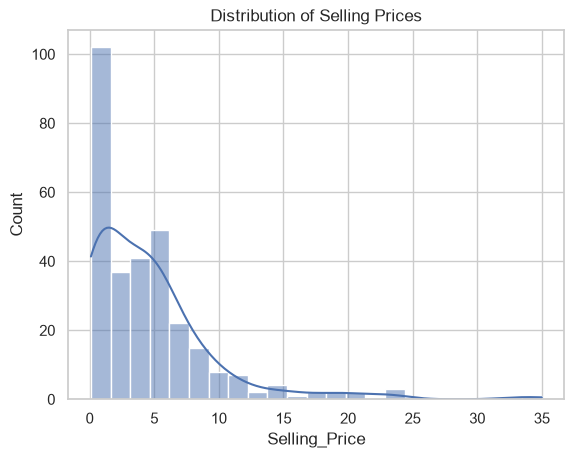

In [3]:
sns.histplot(df.Selling_Price,kde=True); plt.title("Distribution of Selling Prices"); plt.show()

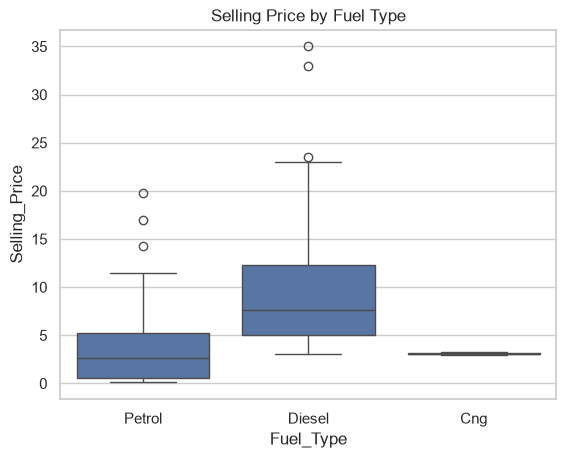

In [4]:
sns.boxplot(data=df,x="Fuel_Type",y="Selling_Price"); plt.title("Selling Price by Fuel Type"); plt.show()

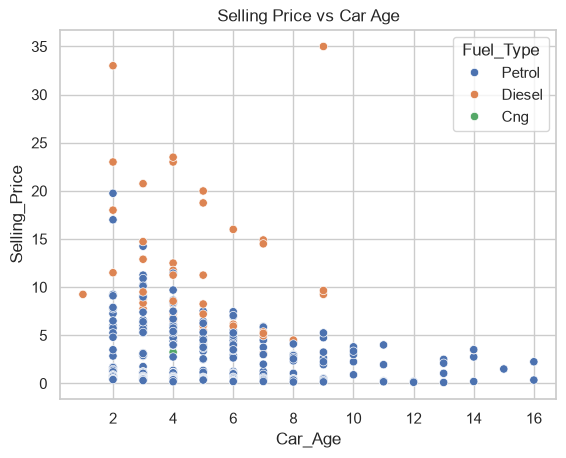

In [5]:
sns.scatterplot(data=df,x="Car_Age",y="Selling_Price",hue="Fuel_Type"); plt.title("Selling Price vs Car Age"); plt.show()

**Observation:** Price generally decreases as cars age, while fuel type and vehicle specifications create additional variation.

## 3. Correlation heatmap

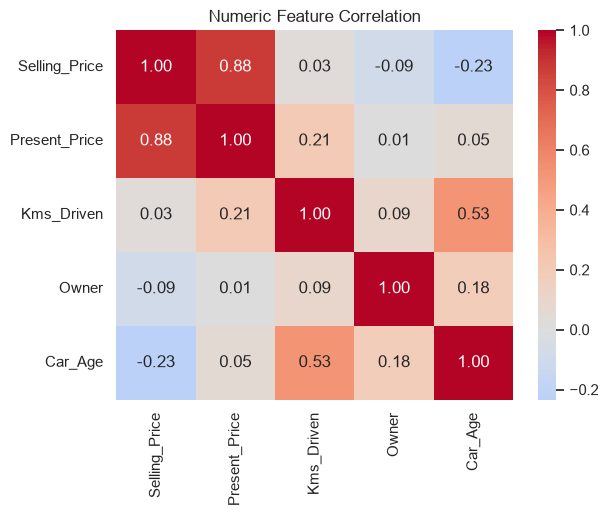

In [6]:
cols=["Selling_Price","Present_Price","Kms_Driven","Owner","Car_Age"]; sns.heatmap(df[cols].corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0); plt.title("Numeric Feature Correlation"); plt.show()

## 4. Split and encode categorical variables

In [7]:
features=["Present_Price","Kms_Driven","Fuel_Type","Seller_Type","Transmission","Owner","Car_Age","Brand"]; X=df[features]; y=df.Selling_Price; Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.20,random_state=42)
num=["Present_Price","Kms_Driven","Owner","Car_Age"]; cat=["Fuel_Type","Seller_Type","Transmission","Brand"]; pre=ColumnTransformer([("num",SimpleImputer(strategy="median"),num),("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore"))]),cat)])

## 5. Train and evaluate 3 regressors

In [8]:
models={"Linear Regression":LinearRegression(),"Random Forest":RandomForestRegressor(n_estimators=400,min_samples_leaf=2,random_state=42),"Gradient Boosting":GradientBoostingRegressor(n_estimators=250,random_state=42)}; results={}
for n,m in models.items():
 p=Pipeline([("pre",pre),("model",m)]); p.fit(Xtr,ytr); pred=p.predict(Xte); results[n]={"pipe":p,"pred":pred,"MAE":mean_absolute_error(yte,pred),"RMSE":np.sqrt(mean_squared_error(yte,pred)),"R2":r2_score(yte,pred)}
metrics=pd.DataFrame({n:{"MAE":r["MAE"],"RMSE":r["RMSE"],"R²":r["R2"]} for n,r in results.items()}).T.sort_values("R²",ascending=False); display(metrics.round(4)); print("Best model:",metrics.index[0])

,MAE,RMSE,R²
Linear Regression,1.3481,2.3890,0.7786
Gradient Boosting,1.0956,2.4964,0.7582
Random Forest,1.3480,3.2199,0.5977


Best model: Linear Regression


## 6. Feature importance

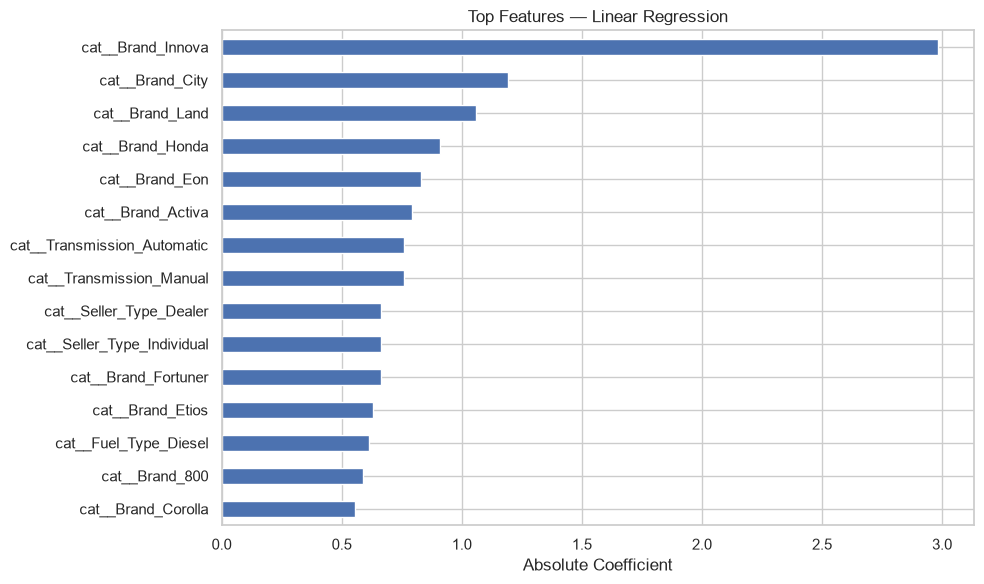

,Coefficient,Absolute Importance
cat__Brand_Innova,2.983641,2.983641
cat__Brand_City,1.194128,1.194128
cat__Brand_Land,-1.060227,1.060227
cat__Brand_Honda,-0.910160,0.910160
cat__Brand_Eon,-0.829739,0.829739
cat__Brand_Activa,-0.791784,0.791784
cat__Transmission_Automatic,0.761360,0.761360
cat__Transmission_Manual,-0.761360,0.761360
cat__Seller_Type_Dealer,0.664839,0.664839
cat__Seller_Type_Individual,-0.664839,0.664839


In [9]:
## 6. Feature importance for the best model

best_name = metrics.index[0]
best_pipe = results[best_name]["pipe"]
best_model = best_pipe.named_steps["model"]

# Get the transformed feature names
feature_names = best_pipe.named_steps["pre"].get_feature_names_out()

# Linear Regression uses coefficients instead of tree feature_importances_
if hasattr(best_model, "coef_"):
    coefficients = pd.Series(
        best_model.coef_,
        index=feature_names
    )

    # Use absolute coefficient magnitude as feature importance
    importance = coefficients.abs().sort_values(ascending=False).head(15)

    importance.sort_values().plot(
        kind="barh",
        figsize=(10, 6)
    )

    plt.title(f"Top Features — {best_name}")
    plt.xlabel("Absolute Coefficient")
    plt.tight_layout()
    plt.show()

    display(
        pd.DataFrame({
            "Coefficient": coefficients[importance.index],
            "Absolute Importance": importance
        }).sort_values("Absolute Importance", ascending=False)
    )

elif hasattr(best_model, "feature_importances_"):
    importance = pd.Series(
        best_model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False).head(15)

    importance.sort_values().plot(
        kind="barh",
        figsize=(10, 6)
    )

    plt.title(f"Top Features — {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    display(importance.to_frame("Importance"))

else:
    print(f"{best_name} does not provide a supported feature-importance measure.")


## Final conclusion

The workflow includes data cleaning, feature engineering, exploratory data analysis, categorical encoding, train/test splitting, and three regression models. The models were evaluated using MAE, RMSE, and R².

Linear Regression achieved the highest R² score of 0.7786 and was selected as the best-performing model. Since Linear Regression uses coefficients rather than tree-based feature_importances_, absolute coefficient magnitude was used to analyze feature importance.

The results provide a baseline for predicting used-car selling prices and show which encoded and numerical features have the strongest relationship with the predicted selling price.